# Age Estimation and Gender Classification

In this assignment, you will train CNN models to estimate a person's age and predict their gender based on face images. Please read carefully all the instructions before you start to write your code.

**Your Tasks**

You are supposed to train two CNN models.
- Model A: Train a CNN model from scratch, following a few restrictions. Save this model as `age_gender_A.keras`
- Model B: Fine-tune a pre-trained model to perform the same task. Save this model as `age_gender_B.keras`

**Dataset**

Your models will be trained and validated on a folder `train_val/` containing 5,000 labeled face images (size: 128 x 128), originated from the UTKFace dataset. During the assessment phase, your code will be tested on unseen test data.

**Performance Metric**

The evaluation of your models on the test set will be based on the following metrics:
- age estimation: - Mean Absolute Error (MAE)
- gender prediction: accuracy

**GPU Time Management**

Please use the available GPU time wisely, as there are some limitations on free GPU usage. It is said the users can use up to 12 hours in row in Google Colab. But many people found they reached its limit far less than 12 hours. To minimize the risk of reaching the limit, consider the following suggestions:
1. Ensure you have a stable internet connection.
2. Carefully validate your hyperparameters before starting the training process.
3. Based on past experience, each model should be trained in less than 2 hours. If the training time is significantly longer, you may need to adjust your model architecture.


## Setting Up: Mount the google drive
Mount your google drive to the notebook. Also don't forget to **enable GPU** before your training.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Visualize a few photos
It's always beneficial to thoroughly understand your data before beginning the training process. To get a first-hand impression of the dataset, please display a minimum of 20 images from the `train_val/` folder, along with their corresponding age and gender labels. This will help you gain initial insights into the dataset.

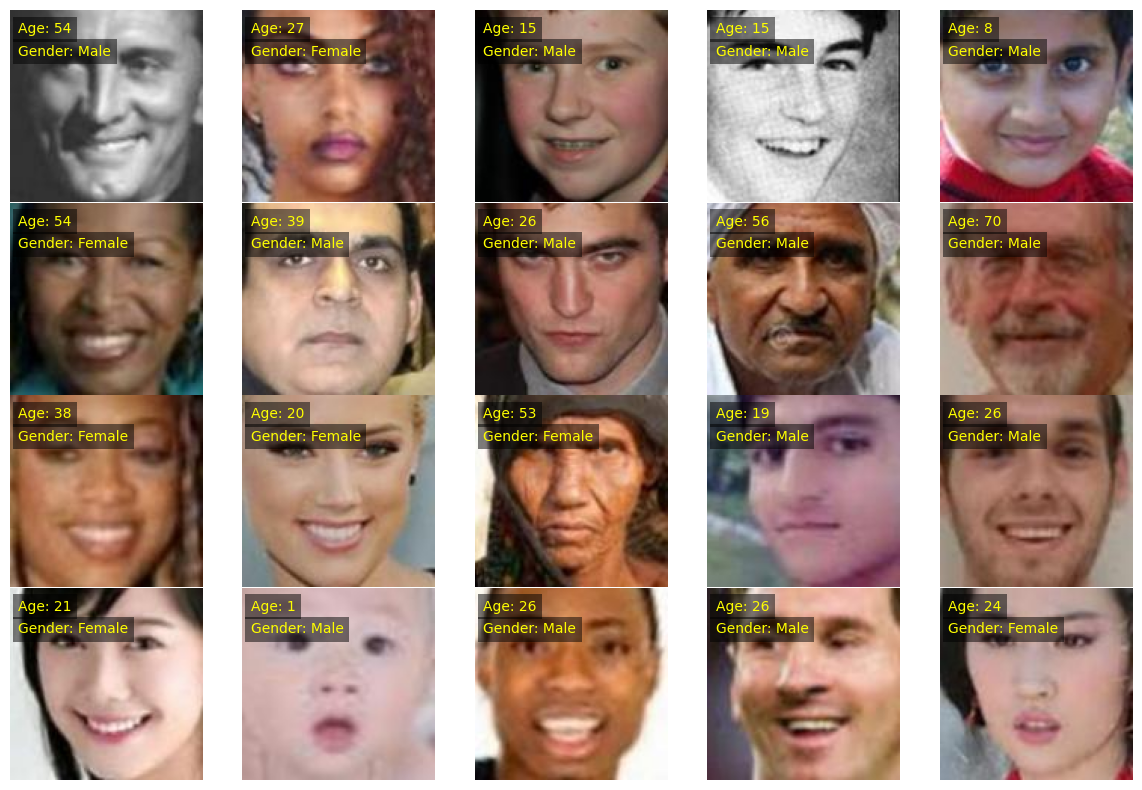

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

folder_train_val = '/content/drive/MyDrive/ML2_cwk_1/train_val'  # the path to train_val

all_image_files = [file for file in os.listdir(folder_train_val) if file.lower().endswith(('.jpg'))]

random.seed(0)  # randomly selects 20 images from the dataset
sample_files = random.sample(all_image_files, 20)

fig, axes = plt.subplots(4, 5, figsize=(15, 10))
plt.subplots_adjust(wspace=0, hspace=0)

for i, filename in enumerate(sample_files):
    # determine row and column indices
    row = i // 5
    col = i % 5
    ax = axes[row][col]

    img_path = os.path.join(folder_train_val, filename)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # converts BGR to RGB matplotlib

    parts = filename.split('_')  # extract labels from file name (assume format: age_gender_*.jpg)
    age_label = parts[0]
    gender_label = parts[1]
    gender_str = "Male" if gender_label == "0" else "Female"

    ax.imshow(img)
    ax.text(5, 15, f"Age: {age_label}", color='yellow', fontsize=10,
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
    ax.text(5, 30, f"Gender: {gender_str}", color='yellow', fontsize=10,
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

    ax.axis('off')

plt.show()


## Step 1: Data Pre-Processing
In this step, you will perform necessary pre-processing tasks before feeding the data into a CNN. The pre-processing includes:

1. Splitting the data into training and validation sets.
2. Loading image data, gender labels and age values, and rescaling pixel values (originally integers between 0 and 255) to the range [0, 1].
3. Data augmentation

The first two pre-processing steps have already been completed for you. Your task in this step is limited to:

3. Data augmentation

Please note:

- Do not modify any part of the provided code except the section marked with ########.
- Do not rescale the age values to the range [0,1], as the original values are used during the testing stage. Rescaling them would significantly impact testing performance.



Number of images for training: 4000
Number of images for validation: 1000
load all image data, age and gender labels...
load all image data, age and gender labels...


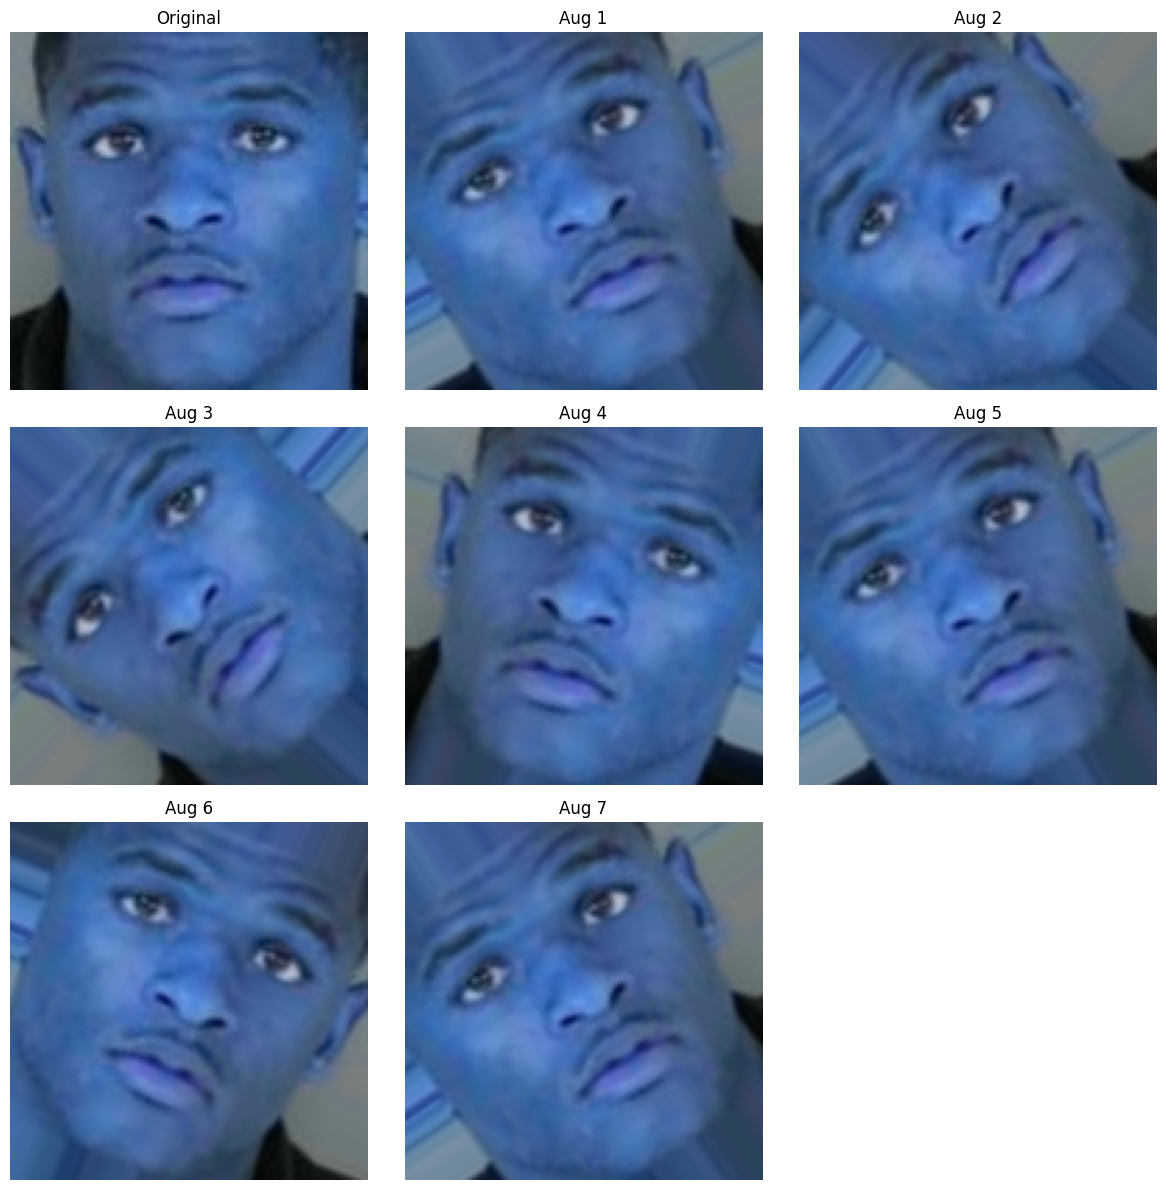

In [ ]:
import os
import random
import numpy as np
from tensorflow.keras.layers import RandomFlip, RandomRotation
import tensorflow as tf

folder_train_val = '/content/drive/MyDrive/ML2_cwk_1/train_val'
all_image_files = [file for file in os.listdir(folder_train_val) if file.lower().endswith(('.jpg'))]

# Shuffle the dataset to ensure random distribution
random.seed(0)  # Ensure reproducibility
random.shuffle(all_image_files)

# Calculate the number of images for each set
n_train_val = len(all_image_files)
train_end = int(n_train_val * 0.8)

# Split the dataset
train_image_files = all_image_files[:train_end]
val_image_files = all_image_files[train_end:]
print(f"Number of images for training: {len(train_image_files)}")
print(f"Number of images for validation: {len(val_image_files)}")

def load_imgs_lables(dataset_path,filenames):
  print('load all image data, age and gender labels...')
  images = []
  age_labels = []
  gender_labels = []
  for current_file_name in filenames:
    img = cv2.imread(os.path.join(dataset_path, current_file_name))
    img = img / 255.0  # Normalize pixel values
    labels = current_file_name.split('_')
    age_label = int(labels[0])
    gender_label = int(labels[1])
    age_labels.append(age_label)
    gender_labels.append(gender_label)
    images.append(img)

  # Convert to NumPy arrays
  images = np.array(images)
  age_labels = np.array(age_labels)
  gender_labels = np.array(gender_labels)
  return images, age_labels, gender_labels

# load data from the training set
train_images, train_age, train_gender = load_imgs_lables(folder_train_val,train_image_files)

# load data from the validation set
val_images, val_age, val_gender = load_imgs_lables(folder_train_val,val_image_files)

#
######### Add your code for data augmentation here #########
######### Add your code for data augmentation here #########

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.15, fill_mode='nearest'),
])

sample_img = train_images[0]  # get the first image for testing

sample_img_expanded = sample_img[np.newaxis, ...]  # expand dimensions of sample image to match expected input shape for augmentation

plt.figure(figsize=(12, 12))

# display original image in first slot
plt.subplot(3, 3, 1)
plt.imshow(sample_img)
plt.axis('off')
plt.title("Original")

# display 7 possile augmented images in the remaining slots
for i in range(7):
    aug_img = data_augmentation(sample_img_expanded)[0]  # get the augmented image
    plt.subplot(3, 3, i+2)  # start from second slot
    plt.imshow(aug_img)
    plt.axis('off')
    plt.title(f"Aug {i+1}")

plt.tight_layout()
plt.show()

## STEP2A: Build your own CNN network
In this step, you will define your own CNN model for identifying gender and predicting age. Although there are two tasks, you only need to build one CNN model with two outputs. You may refer to online resources for solutions.

Here are the key requirements and restrictions for your network:
1.	The input size must be 128 x 128 x 3, which means you **should not resize** the original images. This is because my test code relies on this particular input size. Any other size will cause problem in the testing stage.
2.  Please treat the gender classification as a binary problem, i.e., **the output layer for the gender branch has only 1 unit**, instead of 2. Although it is technically correct to treat gender classification as a multi-class problem with 2 classes, i.e., 2 units in the last layer, the test code only supports a 1-unit last-layer configuration for the gender branch.
3.	The size of feature maps being fed to the first fully connected layer must be less than 10 x 10, while there is no number limitation about the depth.
4.	Incorporate techniques to prevent overfitting as appropriate.

At the end of your implementation, use `modelA.summary()` to display the model architecture and use `plot_model()` to visualize the architecture.

## STEP3A: Compile and train your model
Compile and train your model here.
Save your model by `modelA.save(your_model_folder+"age_gender_A.keras")` after training.

**DON'T use any other name for your model file.** This is because my test code relies on this particular model name. Any other file name will cause problem in the testing stage.

**Save the model with `save()`** to save the entire model (including a model's architecture, weights, and training configuration) as a `.keras` zip archive. Don't save it with `save_weights()`.


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, GlobalAveragePooling2D, Flatten, Dense, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
import graphviz


input_shape = (128, 128, 3)
inputs = Input(shape=input_shape)

x = data_augmentation(inputs, training=True)

# ---------------------- Block 1 ----------------------
x = Conv2D(32, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv2D(32, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = MaxPooling2D(pool_size=(2,2))(x) # 128->64
x = Dropout(0.25)(x)

x = Conv2D(64, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv2D(64, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = MaxPooling2D(pool_size=(2,2))(x) # 64->32
x = Dropout(0.25)(x)

x = Conv2D(128, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv2D(128, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = MaxPooling2D(pool_size=(2,2))(x) # 32->16
x = Dropout(0.25)(x)

x = Conv2D(256, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv2D(256, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = MaxPooling2D(pool_size=(2,2))(x) # 16->8
x = Dropout(0.25)(x)

x_age = Flatten()(x) # Flatten the last conv block for age
x_age = Dense(512)(x_age)
x_age = BatchNormalization()(x_age)
x_age = Activation('relu')(x_age)
x_age = Dropout(0.5)(x_age)

x_gender = Conv2D(512, (3,3), padding='same')(x)
x_gender = BatchNormalization()(x_gender)
x_gender = Activation('relu')(x_gender)

x_gender = Conv2D(512, (3,3), padding='same')(x_gender)
x_gender = BatchNormalization()(x_gender)
x_gender = Activation('relu')(x_gender)

x_gender = MaxPooling2D(pool_size=(2,2))(x_gender) # 8 -> 4
x_gender = Dropout(0.25)(x_gender)

x_gender = Flatten()(x_gender) # Flatten the last conv block for age
x_gender = Dense(512)(x_gender)
x_gender = BatchNormalization()(x_gender)
x_gender = Activation('relu')(x_gender)
x_gender = Dropout(0.5)(x_gender)


age_output = Dense(1, activation='relu', name='age')(x_age) # Regression
gender_output = Dense(1, activation='sigmoid', name='gender')(x_gender)

modelA = Model(inputs=inputs, outputs=[age_output, gender_output])

modelA.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={
        'age': 'mae',
        'gender': 'binary_crossentropy'
    },
    metrics={
        'age': 'mae',
        'gender': 'accuracy'
    }
)

# callbacks to prevent overfitting
callbacks = [
    EarlyStopping(monitor='val_loss', min_delta = 0.001, patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', min_delta = 0.005, factor=0.5, patience=3, min_lr=1e-6)
]

history = modelA.fit(
    train_images,
    {'age': train_age, 'gender': train_gender},
    validation_data=(val_images, {'age': val_age, 'gender': val_gender}),
    epochs=100,
    batch_size=32,
    callbacks=callbacks
)

your_model_folder = '/content/drive/MyDrive/ML2_cwk_1/model_A/'

os.makedirs(your_model_folder, exist_ok=True)

try:
    modelA.save(your_model_folder + "age_gender_A.keras")
    print("Model saved successfully.")
except Exception as e:
    print(f"Error saving model: {e}")

modelA.summary()

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 148ms/step - age_loss: 27.3670 - age_mae: 27.3670 - gender_accuracy: 0.5649 - gender_loss: 0.8524 - loss: 28.2194 - val_age_loss: 18.6711 - val_age_mae: 18.7002 - val_gender_accuracy: 0.5780 - val_gender_loss: 0.7182 - val_loss: 19.4145 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 137ms/step - age_loss: 14.4218 - age_mae: 14.4218 - gender_accuracy: 0.6130 - gender_loss: 0.7176 - loss: 15.1394 - val_age_loss: 18.1789 - val_age_mae: 18.2814 - val_gender_accuracy: 0.5830 - val_gender_loss: 1.1216 - val_loss: 19.3955 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 138ms/step - age_loss: 13.7856 - age_mae: 13.7856 - gender_accuracy: 0.6316 - gender_loss: 0.6694 - loss: 14.4550 - val_age_loss: 14.1556 - val_age_mae: 14.1874 - val_gender_accuracy: 0.7010 - val_gender_loss: 0.6023 - val_loss: 14.7889 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - age_loss: 12.8465 - age_

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ sequential (Sequential)   │ (None, 128, 128, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 32)   │            896 │ sequential[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 128, 128, 32)   │            128 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 128, 128, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 32)   │          9,248 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 128, 128, 32)   │            128 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 128, 128, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 32)     │              0 │ activation_1[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 64, 64, 32)     │              0 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 64)     │         18,496 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 64, 64, 64)     │            256 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 64, 64, 64)     │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 64)     │         36,928 │ activation_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 64, 64, 64)     │            256 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 64, 64, 64)     │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1      

 Total params: 51,915,624 (198.04 MB)

 Trainable params: 17,303,202 (66.01 MB)

 Non-trainable params: 6,016 (23.50 KB)

 Optimizer params: 34,606,406 (132.01 MB)

## STEP4A: Draw the learning curves
Draw four learning curve figures for model A as follows.
1.	The loss of the gender classification over the training and validation set
2.	The accuracy of the gender classification over the training and validation set
3.	The loss of the age estimation over the training and validation set
4.	The MAE of the age estimation over the training and validation set

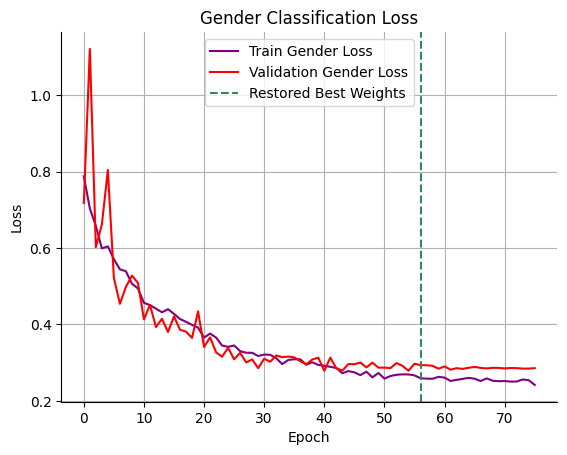

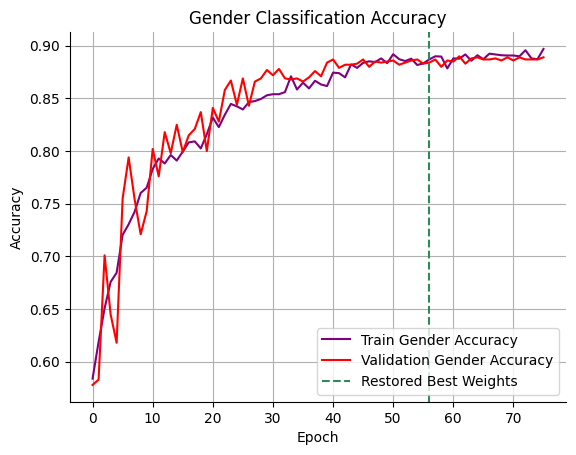

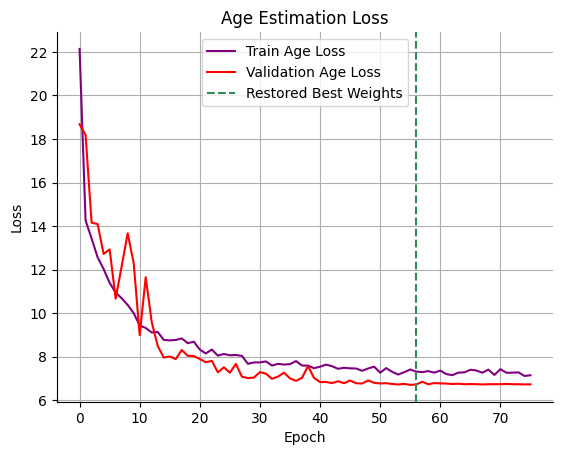

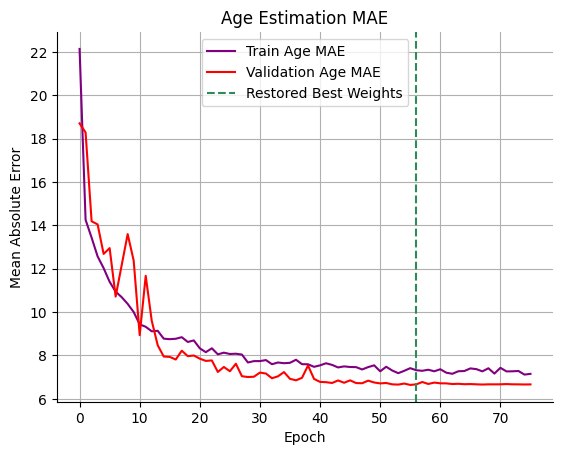


Final Metrics:
Final Validation Gender Classification Loss: 0.2854968309402466
Final Train Gender Classification Loss: 0.24160820245742798
Final Validation Gender Classification Accuracy: 0.8889999985694885
Final Train Gender Classification Accuracy: 0.8970000147819519
Final Validation Age Estimation Loss: 6.735077381134033
Final Train Age Estimation Loss: 7.152365684509277
Final Validation Age Estimation MAE: 6.666466236114502
Final Train Age Estimation MAE: 7.152365684509277

Best Weights Were Restored from Epoch after Early Stopping Flag Raised: 56
Best Validation Gender Loss: 0.2970953583717346
Corresponding Train Gender Loss: 0.2666074335575104
Best Validation Gender Accuracy: 0.8830000162124634
Corresponding Train Gender Accuracy: 0.8832499980926514
Best Validation Age Loss: 6.7079596519470215
Corresponding Train Age Loss: 7.415042400360107
Best Validation Age MAE: 6.642347812652588
Corresponding Train Age MAE: 7.415042400360107


In [ ]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

best_epoch = np.argmin(history.history['val_loss']) + 1  # Adding 1 since epochs start at 1
gender_loss = history.history['gender_loss']
val_gender_loss = history.history['val_gender_loss']
gender_accuracy = history.history['gender_accuracy']
val_gender_accuracy = history.history['val_gender_accuracy']
age_loss = history.history['age_loss']
val_age_loss = history.history['val_age_loss']
age_mae = history.history['age_mae']
val_age_mae = history.history['val_age_mae']

# Gender classification loss
plt.figure()
plt.plot(history.history['gender_loss'], label='Train Gender Loss', color='purple')
plt.plot(history.history['val_gender_loss'], label='Validation Gender Loss', color='red')
plt.axvline(x=best_epoch, color='seagreen', linestyle='--', label='Restored Best Weights')
plt.title('Gender Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.savefig(your_model_folder + 'gender_classification_loss.png')
plt.show()

# Gender classification accuracy
plt.figure()
plt.plot(history.history['gender_accuracy'], label='Train Gender Accuracy', color='purple')
plt.plot(history.history['val_gender_accuracy'], label='Validation Gender Accuracy', color='red')
plt.axvline(x=best_epoch, color='seagreen', linestyle='--', label='Restored Best Weights')
plt.title('Gender Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.savefig(your_model_folder + 'gender_classification_accuracy.png')
plt.show()

# Age estimation loss
plt.figure()
plt.plot(history.history['age_loss'], label='Train Age Loss', color='purple')
plt.plot(history.history['val_age_loss'], label='Validation Age Loss', color='red')
plt.axvline(x=best_epoch, color='seagreen', linestyle='--', label='Restored Best Weights')
plt.title('Age Estimation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.savefig(your_model_folder + 'age_estimation_loss_mae.png')
plt.show()

# Age estimation MAE
plt.figure()
plt.plot(history.history['age_mae'], label='Train Age MAE', color='purple')
plt.plot(history.history['val_age_mae'], label='Validation Age MAE', color='red')
plt.axvline(x=best_epoch, color='seagreen', linestyle='--', label='Restored Best Weights')
plt.title('Age Estimation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.savefig(your_model_folder + 'age_estimation_mae.png')
plt.show()

print("\nFinal Metrics:")
print(f"Final Validation Gender Classification Loss: {val_gender_loss[-1]}")
print(f"Final Train Gender Classification Loss: {gender_loss[-1]}", end='\n')

print(f"Final Validation Gender Classification Accuracy: {val_gender_accuracy[-1]}")
print(f"Final Train Gender Classification Accuracy: {gender_accuracy[-1]}", end='\n')

print(f"Final Validation Age Estimation Loss: {val_age_loss[-1]}")
print(f"Final Train Age Estimation Loss: {age_loss[-1]}", end='\n')

print(f"Final Validation Age Estimation MAE: {val_age_mae[-1]}")
print(f"Final Train Age Estimation MAE: {age_mae[-1]}", end='\n')

# Print Restored Metrics After Fine-Tuning
print(f"\nBest Weights Were Restored from Epoch after Early Stopping Flag Raised: {best_epoch}")
print(f"Best Validation Gender Loss: {val_gender_loss[best_epoch - 1]}")
print(f"Corresponding Train Gender Loss: {gender_loss[best_epoch - 1]}", end = '\n')

print(f"Best Validation Gender Accuracy: {val_gender_accuracy[best_epoch - 1]}")
print(f"Corresponding Train Gender Accuracy: {gender_accuracy[best_epoch - 1]}", end = '\n')

print(f"Best Validation Age Loss: {val_age_loss[best_epoch - 1]}")
print(f"Corresponding Train Age Loss: {age_loss[best_epoch - 1]}", end = '\n')

print(f"Best Validation Age MAE: {val_age_mae[best_epoch - 1]}")
print(f"Corresponding Train Age MAE: {age_mae[best_epoch - 1]}", end = '\n')



## STEP2B: Build a CNN network based on a pre-trained model
Choose an existing CNN architecture pre-trained on ImageNet and fine-tune it on this dataset.

As with Model A, **do not resize the input image size**.
Ensure that the output layer for **the gender branch has only 1 unit**.

At the end of the cell, use `modelB.summary()` to display the model architecture and use `plot_model()` to visualize the architecture.


## STEP3B: Compile and train your model
Compile and train your model here.
Save your model to `age_gender_B.keras` after training.

**DON'T use any other name for your model file.** This is because my test code relies on this particular model name. Any other file name will cause problem in the testing stage.

**Also, save the model with `save()` instead of `save_weights()`.**


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - age_loss: 31.1983 - age_mae: 31.1983 - gender_accuracy: 0.7145 - gender_loss: 0.7364 - loss: 41.1351 - val_age_loss: 20.4838 - val_age_mae: 20.6157 - val_gender_accuracy: 0.7910 - val_gender_loss: 0.4621 - val_loss: 24.5107 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - age_loss: 13.9129 - age_mae: 13.9129 - gender_accuracy: 0.7621 - gender_loss: 0.4987 - loss: 17.8778 - val_age_loss: 16.3688 - val_age_mae: 16.4774 - val_gender_accuracy: 0.7920 - val_gender_loss: 0.4605 - val_loss: 20.2263 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - age_loss: 10.6320 - age_mae: 10.6320 - gender_accuracy: 0.7612 - gender_loss: 0.4928 - loss: 14.2631 - val_age_loss: 10.0217 - val_age_mae: 9.9768 - val_gender_accuracy: 0.8120 - val_gender_loss: 0.4324 - val_loss: 13.1314 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ sequential (Sequential)   │ (None, 128, 128, 3)    │              0 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vgg16 (Functional)        │ (None, 4, 4, 512)      │     14,714,688 │ sequential[1][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_2 (Flatten)       │ (None, 8192)           │              0 │ vgg16[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 1024)           │      8,389,632 │ flatten_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_12    │ (None, 1024)           │          4,096 │ dense_2[0][0]          │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_7 (Dropout)       │ (None, 1024)           │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ age (Dense)               │ (None, 1)              │          1,025 │ dropout_7[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gender (Dense)            │ (None, 1)              │          1,025 │ dropout_7[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 69,327,304 (264.46 MB)

 Trainable params: 23,108,418 (88.15 MB)

 Non-trainable params: 2,048 (8.00 KB)

 Optimizer params: 46,216,838 (176.30 MB)

Model saved successfully.


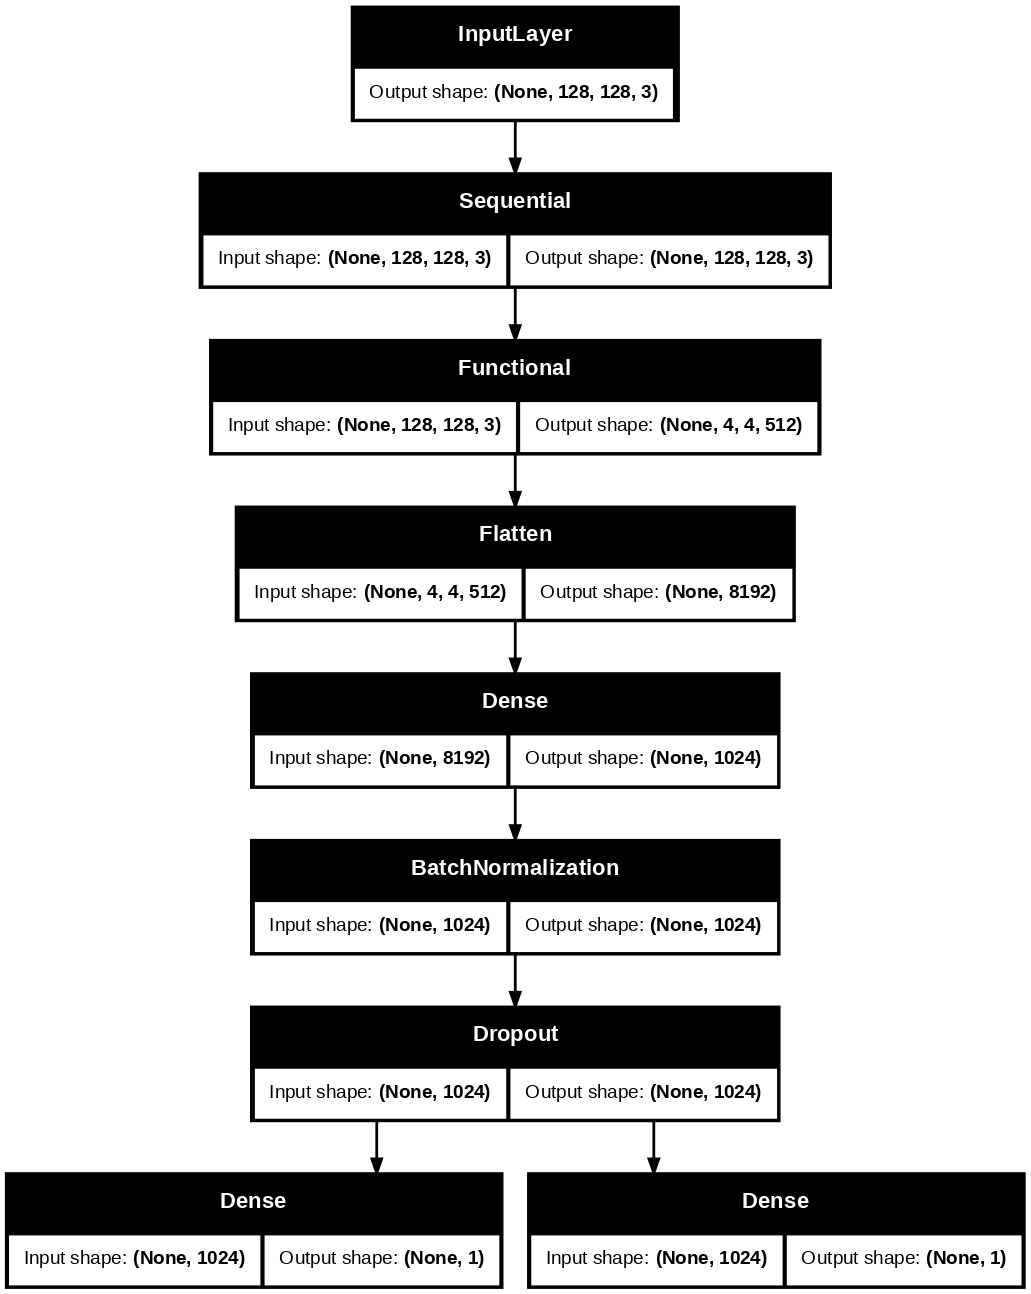

In [ ]:
#
# Add your code here
#
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

input_shape = (128, 128, 3)
inputs = Input(shape=input_shape)

x = data_augmentation(inputs, training=True)

# load pre-trained VGG16 model without its classifer (top=False)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

base_model.trainable = False  # freeze all layers (unfreeze top layers later (vgg16 classifier still not included in model so that isnt unfrozen later))

x = base_model(x, training=False)  # training=False ensures batch normalisation layers in vgg16 does not update during training

# new custom layers
x = Flatten()(x)
x = Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

age_output = Dense(1, name='age')(x)

gender_output = Dense(1, activation='sigmoid', name='gender')(x)

modelB = Model(inputs=inputs, outputs=[age_output, gender_output])

modelB.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={
        'age': 'mae',
        'gender': 'binary_crossentropy'
    },
    metrics={
        'age': 'mae',
        'gender': 'accuracy'
    }
)

# callbacks to prevent overfitting
callbacks = [
    EarlyStopping(monitor='val_loss', min_delta = 0.001, patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', min_delta = 0.005, factor=0.5, patience=3, min_lr=1e-6)
]

history = modelB.fit(
    train_images,
    {'age': train_age, 'gender': train_gender},
    validation_data=(val_images, {'age': val_age, 'gender': val_gender}),
    epochs=100,
    batch_size=32,
    callbacks=callbacks
)

# unfreeze some layers in vgg16
for layer in base_model.layers[-20:]:
    layer.trainable = True

# compile the model again with lower learning rate for fine-tuning
modelB.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss={
        'age': 'mae',
        'gender': 'binary_crossentropy'
    },
    metrics={
        'age': 'mae',
        'gender': 'accuracy'
    }
)

callbacks_2 = [
    EarlyStopping(monitor='val_loss', min_delta = 0.001, patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', min_delta = 0.005, factor=0.5, patience=3, min_lr=1e-6)
]

# fit the model again
history_fine_tune = modelB.fit(
    train_images,
    {'age': train_age, 'gender': train_gender},
    validation_data=(val_images, {'age': val_age, 'gender': val_gender}),
    epochs=100,
    batch_size=32,
    callbacks=callbacks_2
)


your_model_folder = '/content/drive/MyDrive/ML2_cwk_1/model_B/'

os.makedirs(your_model_folder, exist_ok=True)

modelB.summary()

try:
    modelB.save(your_model_folder + "age_gender_B.keras")
    print("Model saved successfully.")
except Exception as e:
    print(f"Error saving model: {e}")

plot_model(modelB, show_shapes=True, dpi=100, to_file=your_model_folder + "modelB_architecture.png")

## STEP4B: Draw the learning curves
Draw four learning curve figures for model B as follows.
1. The loss of the gender classification over the training and validation set
2. The accuracy of the gender classification over the training and validation set
3. The loss of the age estimation over the training and validation set
4. The MAE of the age estimation over the training and validation set

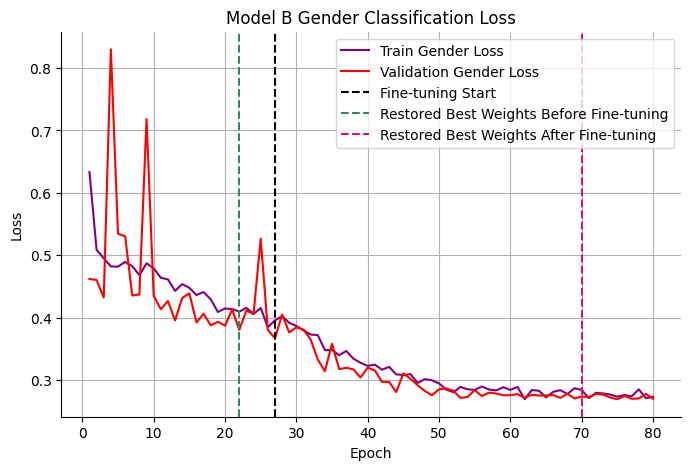

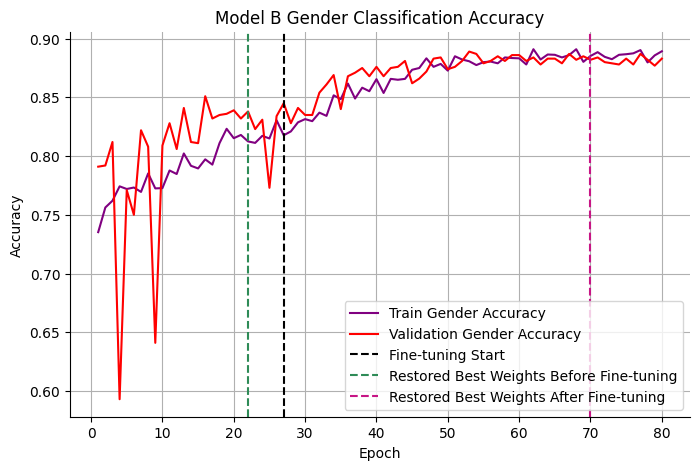

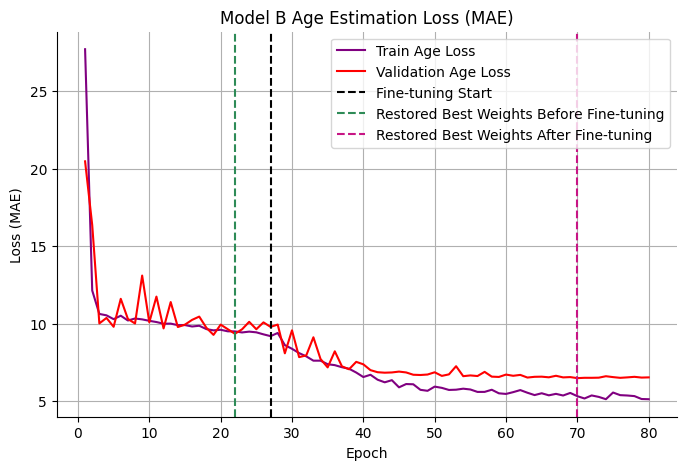

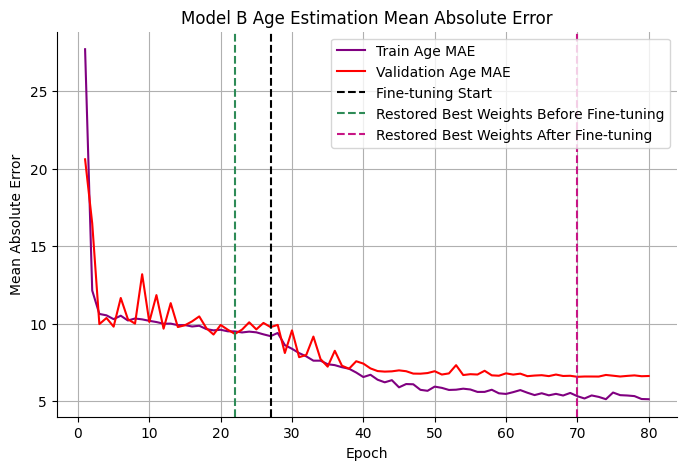


Final Metrics After Fine-Tuning:
Final Validation Gender Classification Loss: 0.2702785134315491
Final Train Gender Classification Loss: 0.2735753357410431
Final Validation Gender Classification Accuracy: 0.8830000162124634
Final Train Gender Classification Accuracy: 0.8892499804496765
Final Validation Age Estimation Loss: 6.537078857421875
Final Train Age Estimation Loss: 5.127042770385742
Final Validation Age Estimation MAE: 6.626319408416748
Final Train Age Estimation MAE: 5.127042770385742

Best Weights Were Restored from Epoch: 70
Best Validation Gender Loss: 0.27379468083381653
Corresponding Train Gender Loss: 0.2843177318572998
Best Validation Gender Accuracy: 0.8820000290870667
Corresponding Train Gender Accuracy: 0.8852499723434448
Best Validation Age Loss: 6.488128662109375
Corresponding Train Age Loss: 5.3225297927856445
Best Validation Age MAE: 6.574451446533203
Corresponding Train Age MAE: 5.3225297927856445


In [ ]:
#
# Add your code here
#
import matplotlib.pyplot as plt

finetune_start = len(history.history['gender_loss'])  # get the number of initial training epochs before fine-tuning
best_epoch_frozen = np.argmin(history.history['val_loss']) + 1  # adding 1 since epochs start at 1
best_epoch_finetune = np.argmin(history_fine_tune.history['val_loss']) + 1 + finetune_start

gender_loss = history.history['gender_loss'] + history_fine_tune.history['gender_loss']
val_gender_loss = history.history['val_gender_loss'] + history_fine_tune.history['val_gender_loss']
gender_accuracy = history.history['gender_accuracy'] + history_fine_tune.history['gender_accuracy']
val_gender_accuracy = history.history['val_gender_accuracy'] + history_fine_tune.history['val_gender_accuracy']
age_loss = history.history['age_loss'] + history_fine_tune.history['age_loss']
val_age_loss = history.history['val_age_loss'] + history_fine_tune.history['val_age_loss']
age_mae = history.history['age_mae'] + history_fine_tune.history['age_mae']
val_age_mae = history.history['val_age_mae'] + history_fine_tune.history['val_age_mae']

epochs = range(1, len(gender_loss) + 1)

# Gender Classification Loss Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, gender_loss, label='Train Gender Loss', color='purple')
plt.plot(epochs, val_gender_loss, label='Validation Gender Loss', color='red')
plt.axvline(x=finetune_start, color='black', linestyle='--', label='Fine-tuning Start')
plt.axvline(x=best_epoch_frozen, color='seagreen', linestyle='--', label='Restored Best Weights Before Fine-tuning')
plt.axvline(x=best_epoch_finetune, color='mediumvioletred', linestyle='--', label='Restored Best Weights After Fine-tuning')
plt.title('Model B Gender Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.savefig(your_model_folder + 'gender_classification_loss.png')
plt.show()

# Gender Classification Accuracy Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, gender_accuracy, label='Train Gender Accuracy', color='purple')
plt.plot(epochs, val_gender_accuracy, label='Validation Gender Accuracy', color='red')
plt.axvline(x=finetune_start, color='black', linestyle='--', label='Fine-tuning Start')
plt.axvline(x=best_epoch_frozen, color='seagreen', linestyle='--', label='Restored Best Weights Before Fine-tuning')
plt.axvline(x=best_epoch_finetune, color='mediumvioletred', linestyle='--', label='Restored Best Weights After Fine-tuning')
plt.title('Model B Gender Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.savefig(your_model_folder + 'gender_classification_accuracy.png')
plt.show()

# Age Estimation Loss (MAE)
plt.figure(figsize=(8, 5))
plt.plot(epochs, age_loss, label='Train Age Loss', color='purple')
plt.plot(epochs, val_age_loss, label='Validation Age Loss', color='red')
plt.axvline(x=finetune_start, color='black', linestyle='--', label='Fine-tuning Start')
plt.axvline(x=best_epoch_frozen, color='seagreen', linestyle='--', label='Restored Best Weights Before Fine-tuning')
plt.axvline(x=best_epoch_finetune, color='mediumvioletred', linestyle='--', label='Restored Best Weights After Fine-tuning')
plt.title('Model B Age Estimation Loss (MAE)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.grid(True)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.savefig(your_model_folder + 'age_estimation_loss_mae.png')
plt.show()

# Age Estimation MAE Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, age_mae, label='Train Age MAE', color='purple')
plt.plot(epochs, val_age_mae, label='Validation Age MAE', color='red')
plt.axvline(x=finetune_start, color='black', linestyle='--', label='Fine-tuning Start')
plt.axvline(x=best_epoch_frozen, color='seagreen', linestyle='--', label='Restored Best Weights Before Fine-tuning')
plt.axvline(x=best_epoch_finetune, color='mediumvioletred', linestyle='--', label='Restored Best Weights After Fine-tuning')
plt.title('Model B Age Estimation Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.savefig(your_model_folder + 'age_estimation_mae.png')
plt.show()

# Print Final Metrics After Fine-Tuning
print("\nFinal Metrics After Fine-Tuning:")
print(f"Final Validation Gender Classification Loss: {val_gender_loss[-1]}")
print(f"Final Train Gender Classification Loss: {gender_loss[-1]}", end='\n')

print(f"Final Validation Gender Classification Accuracy: {val_gender_accuracy[-1]}")
print(f"Final Train Gender Classification Accuracy: {gender_accuracy[-1]}", end='\n')

print(f"Final Validation Age Estimation Loss: {val_age_loss[-1]}")
print(f"Final Train Age Estimation Loss: {age_loss[-1]}", end='\n')

print(f"Final Validation Age Estimation MAE: {val_age_mae[-1]}")
print(f"Final Train Age Estimation MAE: {age_mae[-1]}", end='\n')

# Print Restored Metrics After Fine-Tuning
print(f"\nBest Weights Were Restored from Epoch: {best_epoch_finetune}")
print(f"Best Validation Gender Loss: {val_gender_loss[best_epoch_finetune - 1]}")
print(f"Corresponding Train Gender Loss: {gender_loss[best_epoch_finetune - 1]}", end = '\n')

print(f"Best Validation Gender Accuracy: {val_gender_accuracy[best_epoch_finetune - 1]}")
print(f"Corresponding Train Gender Accuracy: {gender_accuracy[best_epoch_finetune - 1]}", end = '\n')

print(f"Best Validation Age Loss: {val_age_loss[best_epoch_finetune - 1]}")
print(f"Corresponding Train Age Loss: {age_loss[best_epoch_finetune - 1]}", end = '\n')

print(f"Best Validation Age MAE: {val_age_mae[best_epoch_finetune - 1]}")
print(f"Corresponding Train Age MAE: {age_mae[best_epoch_finetune - 1]}", end = '\n')




## STEP5: Evaluate the model on the test set
I will load your two models for testing. The test set will not be available before your submission.

The metrics for measuring the performance on the test set are:
- age estimation: MAE (Mean Absolute Error)
- gender classification: accuracy


In [ ]:
#
# Don't add code in this cell when submitting this file
#